# E3 Transferability & Permutation Equivariance Results

Accuracy plots for the three E3 conditions, averaged across seeds where available.

| Label | Run ID(s) | Description |
|-------|-----------|-------------|
| **BASELINE** | `0sy9j5rz` | LLM-only, new training data |
| **GT** | `bzqt4zxt` | RPEARL-GT (ground-truth graph), no edges in text |
| **RPEARL** | `qmu8x2qu`, `5lj61ocy` | RPEARL (predicted graph), no edges in text — 2 seeds |

In [62]:
import json
import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ── Config ────────────────────────────────────────────────────────────
E3_DIR        = "../outputs/e3_new_training_data"
TRANSFER_DIR  = "../results"
DATA_DIR      = "../data/eval/transferability_data_v1"
SEED_DIRS     = ["perm_32", "perm_42", "perm_58"]
GRAPH_SIZES   = [10, 30, 50, 100, 250, 500, 1000]

# Map run-id suffix → condition label
RUN_TO_CONDITION = {
    "0sy9j5rz": "BASELINE",
    "bzqt4zxt": "GT",
    "qmu8x2qu": "RPEARL",
    ##"5lj61ocy": "RPEARL",
}

CONDITION_COLORS = {
    "BASELINE": "#2196F3",
    "GT":       "#4CAF50",
    "RPEARL":   "#FF9800",
}

# Dataset — `eval_graph_unique_{N}.json`

Eval files in `data/eval/transferability_data_v1/`. Each file is **one** scene graph plus 10 hand-written tasks. The graph has two node types — `objects` and `regions` — and two edge types:

- `object_connections`: object → region (which region holds each object)
- `region_connections`: region ↔ region adjacency

The filename suffix `N` is the *unique-objects* tier; the actual node count grows roughly with `N` but **edges grow super-linearly** because region adjacency densifies fast. This matters for context size: at `N=1000` the prompt encodes ~35k edges, which is what eventually OOMs the 24 GB GPU at the largest tier.

In [63]:
data_records = []
for size in GRAPH_SIZES:
    fp = os.path.join(DATA_DIR, f"eval_graph_unique_{size}.json")
    if not os.path.exists(fp):
        print(f"WARN: missing {fp}")
        continue
    with open(fp) as f:
        d = json.load(f)
    g = d["graph"]
    n_obj = len(g.get("objects", []))
    n_reg = len(g.get("regions", []))
    n_oc  = len(g.get("object_connections", []))
    n_rc  = len(g.get("region_connections", []))
    data_records.append({
        "graph_size":  size,
        "objects":     n_obj,
        "regions":     n_reg,
        "total_nodes": n_obj + n_reg,
        "object_conn": n_oc,
        "region_conn": n_rc,
        "total_edges": n_oc + n_rc,
        "tasks":       len(d["tasks"]),
    })

df_data = pd.DataFrame(data_records).set_index("graph_size")
df_data.style.format("{:,}")

,objects,regions,total_nodes,object_conn,region_conn,total_edges,tasks
graph_size,,,,,,,
10,4,8,12,4,10,14,10
30,4,24,28,4,62,66,10
50,6,40,46,6,128,134,10
100,27,75,102,27,440,467,10
250,62,192,254,62,"2,567","2,629",10
500,133,385,518,133,"9,539","9,672",10
1000,222,768,990,222,"34,931","35,153",10


## Estimated prompt-token budget per task

Rough back-of-the-envelope estimate of how many input tokens the LLM sees per task as the graph grows. Heuristic:

1. Serialize the full graph to compact JSON → `graph_chars`
2. Add the task text → `avg_prompt_chars`
3. Divide by **4 chars/token** (rule-of-thumb for English/structured text)

This **ignores** the system prompt, examples, and any agent-specific scaffolding, and assumes the entire graph is shoved into context (worst case for the LLM-only baseline; the RPEARL conditions encode the graph as embeddings, so their textual prompt is much smaller). Treat as an upper bound for the text-only path.

In [82]:
CHARS_PER_TOKEN = 4  # rough heuristic for English / structured text

token_records = []
for size in GRAPH_SIZES:
    fp = os.path.join(DATA_DIR, f"eval_graph_unique_{size}.json")
    if not os.path.exists(fp):
        continue
    with open(fp) as f:
        d = json.load(f)

    # Per-task prompt ≈ full-graph context (json-serialized) + task text
    graph_chars = len(json.dumps(d["graph"]))
    task_chars = [
        len(t["task"]) if isinstance(t, dict) else len(str(t))
        for t in d["tasks"]
    ]
    avg_task_chars = sum(task_chars) / len(task_chars)
    avg_prompt_chars = graph_chars + avg_task_chars

    token_records.append({
        "graph_size":       size,
        "graph_chars":      graph_chars,
        "avg_task_chars":   round(avg_task_chars, 1),
        "avg_prompt_chars": round(avg_prompt_chars, 1),
        "est_tokens":       int(round(avg_prompt_chars / CHARS_PER_TOKEN)),
    })

df_tokens = pd.DataFrame(token_records).set_index("graph_size")
df_tokens.style.format({
    "graph_chars":      "{:,}",
    "avg_task_chars":   "{:,.1f}",
    "avg_prompt_chars": "{:,.1f}",
    "est_tokens":       "{:,}",
})

,graph_chars,avg_task_chars,avg_prompt_chars,est_tokens
graph_size,,,,
10,"1,293",48.7,"1,341.7",335
30,"3,935",58.4,"3,993.4",998
50,"8,400",54.0,"8,454.0","2,114"
100,"19,988",42.3,"20,030.3","5,008"
250,"113,378",51.1,"113,429.1","28,357"
500,"375,446",50.1,"375,496.1","93,874"
1000,"1,411,397",49.0,"1,411,446.0","352,862"


# Transferability & Permutation Equivariance — Across Graph Sizes

Final-checkpoint eval results from `results/perm_{32,42,58}/`. Each run was evaluated on `eval_graph_unique_{10,30,50,100,250,500,1000}.json` under three node-permutation seeds (32, 42, 58).

- **Transferability:** mean accuracy across seeds vs. graph size — does the policy still work as the scene grows?
- **Permutation equivariance:** spread across seeds at the same graph size — should be near-zero for an equivariant model.

| Label | Run ID | Description |
|-------|--------|-------------|
| **BASELINE** | `0sy9j5rz` | LLM-only |
| **GT** | `bzqt4zxt` | RPEARL-GT (ground-truth graph) |
| **RPEARL** | `qmu8x2qu` | RPEARL (predicted graph) |

In [84]:
trans_records = []
for seed_dir in SEED_DIRS:
    seed = int(seed_dir.split("_")[1])
    for run_id, condition in RUN_TO_CONDITION.items():
        pattern = os.path.join(TRANSFER_DIR, seed_dir, f"*{run_id}_summary.json")
        matches = glob.glob(pattern)
        if not matches:
            print(f"WARN: no summary for {run_id} in {seed_dir}")
            continue
        with open(matches[0]) as f:
            summary = json.load(f)
        for trial in summary["trials"]:
            m = re.search(r"eval_graph_unique_(\d+)\.json", trial["name"])
            if not m:
                continue
            trans_records.append({
                "run_id":      run_id,
                "condition":   condition,
                "seed":        seed,
                "graph_size":  int(m.group(1)),
                "accuracy":    trial["accuracy"],
                "num_correct": trial["num_correct"],
                "num_total":   trial["num_total"],
                "num_errors":  trial["num_errors"],
            })

df_trans = (
    pd.DataFrame(trans_records)
    .sort_values(["condition", "seed", "graph_size"])
    .reset_index(drop=True)
)
print(
    f"Loaded {len(df_trans)} trials | "
    f"{df_trans.seed.nunique()} seeds × "
    f"{df_trans.condition.nunique()} conditions × "
    f"{df_trans.graph_size.nunique()} graph sizes"
)
df_trans.head(15)

Loaded 63 trials | 3 seeds × 3 conditions × 7 graph sizes


,run_id,condition,seed,graph_size,accuracy,num_correct,num_total,num_errors
0,0sy9j5rz,BASELINE,32,10,0.9,9,10,0
1,0sy9j5rz,BASELINE,32,30,0.9,9,10,0
2,0sy9j5rz,BASELINE,32,50,1.0,10,10,0
3,0sy9j5rz,BASELINE,32,100,0.1,1,10,0
4,0sy9j5rz,BASELINE,32,250,0.0,0,10,10
5,0sy9j5rz,BASELINE,32,500,0.0,0,10,10
6,0sy9j5rz,BASELINE,32,1000,0.0,0,10,10
7,0sy9j5rz,BASELINE,42,10,0.9,9,10,0
8,0sy9j5rz,BASELINE,42,30,0.9,9,10,0
9,0sy9j5rz,BASELINE,42,50,0.8,8,10,0


### Plot — Accuracy vs Graph Size (transferability)

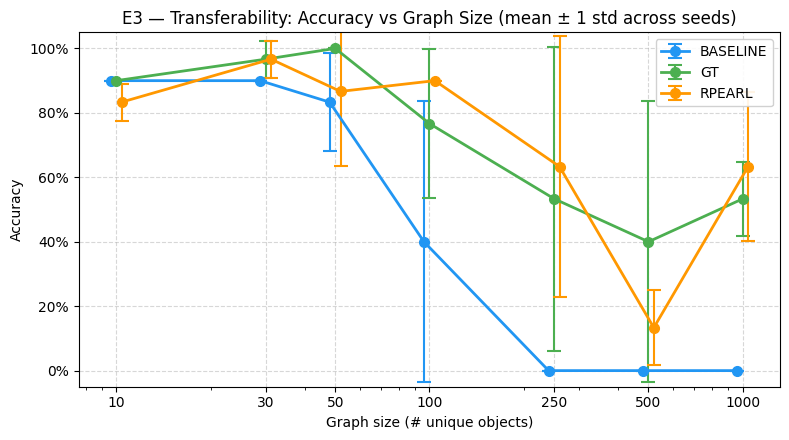

In [86]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# Small horizontal jitter so error bars don't overlap on the log axis
JITTER = {"BASELINE": 0.96, "GT": 1.00, "RPEARL": 1.04}

for condition in ["BASELINE", "GT", "RPEARL"]:
    sub = agg_trans[agg_trans["condition"] == condition].sort_values("graph_size")
    color = CONDITION_COLORS[condition]
    x = sub["graph_size"] * JITTER[condition]
    ax.errorbar(
        x, sub["mean"], yerr=sub["std"],
        marker="o", color=color, label=condition,
        linewidth=2, markersize=7,
        elinewidth=1.5, capsize=5, capthick=1.5,
    )

ax.set_xscale("log")
ax.set_xticks(GRAPH_SIZES)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Graph size (# unique objects)")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(-0.05, 1.05)
ax.set_title("E3 — Transferability: Accuracy vs Graph Size (mean ± 1 std across seeds)")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(axis="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Plot — Per-Seed Accuracy (permutation equivariance)

Three seeds overlaid per condition. Tight bunching across seeds = closer to permutation-equivariant on this task.

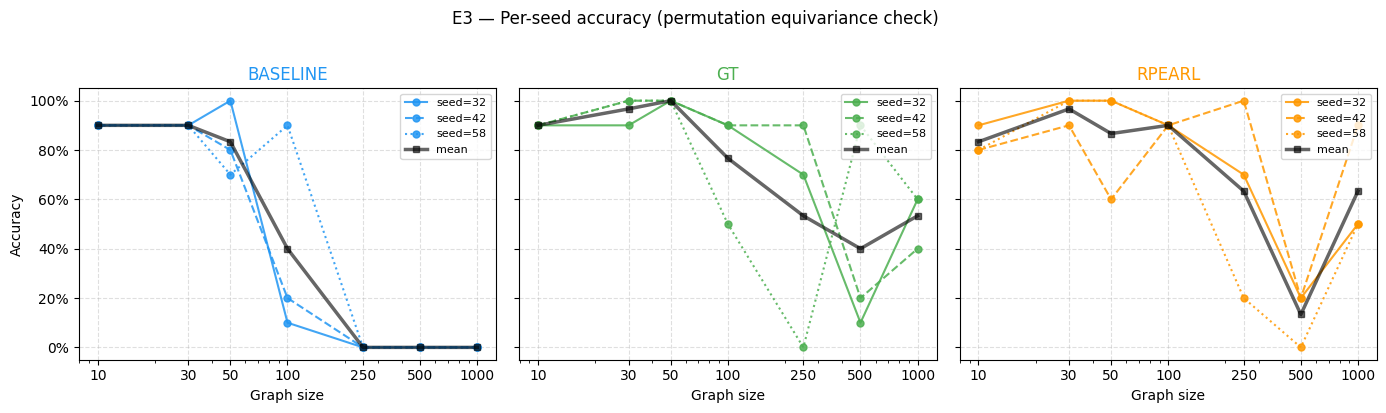

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

seed_styles = {32: "-", 42: "--", 58: ":"}

for ax, condition in zip(axes, ["BASELINE", "GT", "RPEARL"]):
    color = CONDITION_COLORS[condition]
    sub_cond = df_trans[df_trans["condition"] == condition]
    for seed, group in sub_cond.groupby("seed"):
        g = group.sort_values("graph_size")
        ax.plot(
            g["graph_size"], g["accuracy"],
            marker="o", color=color, linestyle=seed_styles.get(seed, "-"),
            label=f"seed={seed}", linewidth=1.5, markersize=5, alpha=0.85,
        )
    # Mean across seeds (heavier black line)
    mean_sub = agg_trans[agg_trans["condition"] == condition].sort_values("graph_size")
    ax.plot(
        mean_sub["graph_size"], mean_sub["mean"],
        marker="s", color="black", linewidth=2.5, markersize=4, alpha=0.6, label="mean",
    )

    ax.set_xscale("log")
    ax.set_xticks(GRAPH_SIZES)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel("Graph size")
    ax.set_title(condition, color=color)
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis="both", linestyle="--", alpha=0.4)
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylabel("Accuracy")
fig.suptitle("E3 — Per-seed accuracy (permutation equivariance check)", y=1.02)
plt.tight_layout()
plt.show()

### Summary table — accuracy (mean ± std across seeds) per graph size

In [71]:
def _fmt(row):
    if row["n"] > 1:
        return f"{row['mean']*100:.0f}% ± {row['std']*100:.0f}%"
    return f"{row['mean']*100:.0f}%"

agg_trans["display"] = agg_trans.apply(_fmt, axis=1)
pivot = (
    agg_trans
    .pivot(index="condition", columns="graph_size", values="display")
    .reindex(index=["BASELINE", "GT", "RPEARL"], columns=GRAPH_SIZES)
)
pivot

graph_size,10,30,50,100,250,500,1000
condition,,,,,,,
BASELINE,90% ± 0%,90% ± 0%,83% ± 15%,40% ± 44%,0% ± 0%,0% ± 0%,0% ± 0%
GT,90% ± 0%,97% ± 6%,100% ± 0%,77% ± 23%,53% ± 47%,40% ± 44%,53% ± 12%
RPEARL,83% ± 6%,97% ± 6%,87% ± 23%,90% ± 0%,63% ± 40%,13% ± 12%,63% ± 23%


### LaTeX table

In [72]:
latex_pivot = pivot.copy()
latex_pivot.index.name = "Condition"
latex_pivot.columns.name = "Graph size"
print(latex_pivot.to_latex(
    caption="E3 Transferability --- Accuracy vs Graph Size (mean $\\pm$ std over 3 seeds)",
    label="tab:e3_transfer_by_size",
    escape=False,
))

\begin{table}
\caption{E3 Transferability --- Accuracy vs Graph Size (mean $\pm$ std over 3 seeds)}
\label{tab:e3_transfer_by_size}
\begin{tabular}{llllllll}
\toprule
Graph size & 10 & 30 & 50 & 100 & 250 & 500 & 1000 \\
Condition &  &  &  &  &  &  &  \\
\midrule
BASELINE & 90% ± 0% & 90% ± 0% & 83% ± 15% & 40% ± 44% & 0% ± 0% & 0% ± 0% & 0% ± 0% \\
GT & 90% ± 0% & 97% ± 6% & 100% ± 0% & 77% ± 23% & 53% ± 47% & 40% ± 44% & 53% ± 12% \\
RPEARL & 83% ± 6% & 97% ± 6% & 87% ± 23% & 90% ± 0% & 63% ± 40% & 13% ± 12% & 63% ± 23% \\
\bottomrule
\end{tabular}
\end{table}



## Failure-mode breakdown per condition

Per-sample outcomes from each `*_eval_graph_unique_*.json`. Each sample carries a `terminated_by` field plus `error` / `correct`. Outcomes are categorised as:

- **correct** — the model gave a correct answer
- **answer** — model produced an answer but it was wrong (semantic / retrieval failure)
- **bad_plan** — planner returned an invalid / unparseable plan
- **max_iterations** — agent loop hit its action-step cap (not the LLM's token cap)
- **OOM** — `terminated_by="exception"` whose error string is a CUDA out-of-memory (prompt no longer fits in GPU memory)
- **exception** — any other exception (none in current logs)

> Note: no failures match `max_new_tokens` / context-window-truncation patterns. The graph-size cliff at the largest sizes is dominated by CUDA OOM on the prompt, not by the LLM's context window.

In [73]:
fail_records = []
for seed_dir in SEED_DIRS:
    seed = int(seed_dir.split("_")[1])
    for run_id, condition in RUN_TO_CONDITION.items():
        for size in GRAPH_SIZES:
            pattern = os.path.join(
                TRANSFER_DIR, seed_dir,
                f"*{run_id}_eval_graph_unique_{size}.json",
            )
            matches = glob.glob(pattern)
            if not matches:
                continue
            with open(matches[0]) as f:
                d = json.load(f)
            for s in d.get("samples", []):
                term = s.get("terminated_by")
                err = s.get("error") or ""
                # Sub-classify exception terminations: CUDA OOM is by far the dominant kind
                if term == "exception":
                    if "out of memory" in err.lower() or "OutOfMemoryError" in err:
                        outcome = "OOM"
                    else:
                        outcome = "exception"
                elif s.get("correct"):
                    outcome = "correct"
                else:
                    outcome = term  # "answer" (wrong), "bad_plan", "max_iterations"

                fail_records.append({
                    "run_id":        run_id,
                    "condition":     condition,
                    "seed":          seed,
                    "graph_size":    size,
                    "terminated_by": term,
                    "correct":       bool(s.get("correct")),
                    "outcome":       outcome,
                })

df_fail = pd.DataFrame(fail_records)
print(f"Loaded {len(df_fail)} samples")
print("\nOverall outcome counts:")
print(df_fail["outcome"].value_counts())
print("\nPer condition:")
print(df_fail.groupby(["condition", "outcome"]).size().unstack(fill_value=0))

Loaded 630 samples

Overall outcome counts:
outcome
correct           393
OOM                92
answer             76
bad_plan           68
max_iterations      1
Name: count, dtype: int64

Per condition:
outcome    OOM  answer  bad_plan  correct  max_iterations
condition                                                
BASELINE    90      27         2       91               0
GT           0      27        30      153               0
RPEARL       2      22        36      149               1


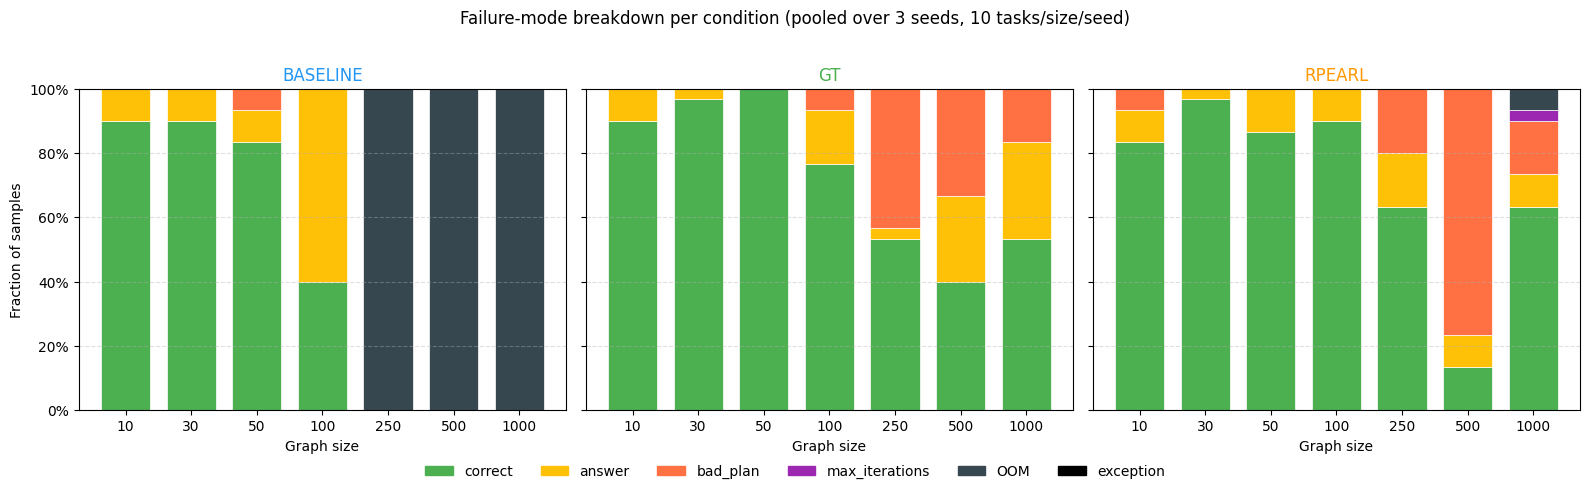

In [74]:
OUTCOME_ORDER = ["correct", "answer", "bad_plan", "max_iterations", "OOM", "exception"]
OUTCOME_COLORS = {
    "correct":        "#4CAF50",
    "answer":         "#FFC107",  # answered but wrong
    "bad_plan":       "#FF7043",
    "max_iterations": "#9C27B0",
    "OOM":            "#37474F",
    "exception":      "#000000",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, condition in zip(axes, ["BASELINE", "GT", "RPEARL"]):
    sub = df_fail[df_fail["condition"] == condition]
    counts = (
        sub.groupby(["graph_size", "outcome"]).size().unstack(fill_value=0)
        .reindex(index=GRAPH_SIZES, fill_value=0)
    )
    fracs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    cols_present = [c for c in OUTCOME_ORDER if c in fracs.columns]
    fracs = fracs.reindex(columns=cols_present, fill_value=0)

    x = np.arange(len(fracs.index))
    bottom = np.zeros(len(fracs.index))
    for outcome in fracs.columns:
        ax.bar(
            x, fracs[outcome].values, bottom=bottom,
            color=OUTCOME_COLORS[outcome], label=outcome,
            edgecolor="white", linewidth=0.5, width=0.75,
        )
        bottom += fracs[outcome].values

    ax.set_xticks(x)
    ax.set_xticklabels(fracs.index)
    ax.set_xlabel("Graph size")
    ax.set_title(condition, color=CONDITION_COLORS[condition])
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("Fraction of samples")

# Single shared legend, ordered consistently
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=OUTCOME_COLORS[o]) for o in OUTCOME_ORDER
]
fig.legend(
    legend_handles, OUTCOME_ORDER,
    loc="lower center", ncol=len(OUTCOME_ORDER),
    bbox_to_anchor=(0.5, -0.05), frameon=False,
)
fig.suptitle("Failure-mode breakdown per condition (pooled over 3 seeds, 10 tasks/size/seed)", y=1.02)
plt.tight_layout()
plt.show()

## Load eval logs

In [75]:
records = []

for run_dir in sorted(os.listdir(E3_DIR)):
    # Extract the run-id (last 8 chars of dir name)
    run_id = run_dir.split("_")[-1]
    if run_id not in RUN_TO_CONDITION:
        continue

    condition = RUN_TO_CONDITION[run_id]
    log_dir = os.path.join(E3_DIR, run_dir, "eval_logs")
    for log_path in sorted(glob.glob(os.path.join(log_dir, "*.json"))):
        with open(log_path) as f:
            d = json.load(f)
        records.append({
            "run_id":    run_id,
            "run_dir":   run_dir,
            "condition": condition,
            "epoch":     int(d["epoch"]),
            "step":      d["step"],
            "accuracy":  d["accuracy"],
            "num_correct": d["num_correct"],
            "num_samples": d["num_samples"],
        })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} eval checkpoints across {df.run_id.nunique()} runs")
df

Loaded 6 eval checkpoints across 3 runs


,run_id,run_dir,condition,epoch,step,accuracy,num_correct,num_samples
0,0sy9j5rz,e3_llm_llama-3.1-8b_r16_4bit_0sy9j5rz,BASELINE,1,225,0.5,5,10
1,0sy9j5rz,e3_llm_llama-3.1-8b_r16_4bit_0sy9j5rz,BASELINE,2,450,0.9,9,10
2,bzqt4zxt,e3_rpearl_gt_llm_llama-3.1-8b_r16_4bit_bzqt4zxt,GT,1,225,0.0,0,10
3,bzqt4zxt,e3_rpearl_gt_llm_llama-3.1-8b_r16_4bit_bzqt4zxt,GT,2,450,0.1,1,10
4,qmu8x2qu,e3_rpearl_llm_llama-3.1-8b_r16_4bit_qmu8x2qu,RPEARL,1,225,0.0,0,10
5,qmu8x2qu,e3_rpearl_llm_llama-3.1-8b_r16_4bit_qmu8x2qu,RPEARL,2,450,0.0,0,10


## Summary: mean ± std per condition per epoch

In [76]:
agg = (
    df.groupby(["condition", "epoch"])["accuracy"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)
agg["std"] = agg["std"].fillna(0.0)   # single-seed → std=0
agg["mean_pct"] = (agg["mean"] * 100).round(1)
agg["std_pct"]  = (agg["std"]  * 100).round(1)
print(agg.to_string(index=False))

condition  epoch  mean  std  n  mean_pct  std_pct
 BASELINE      1   0.5  0.0  1      50.0      0.0
 BASELINE      2   0.9  0.0  1      90.0      0.0
       GT      1   0.0  0.0  1       0.0      0.0
       GT      2   0.1  0.0  1      10.0      0.0
   RPEARL      1   0.0  0.0  1       0.0      0.0
   RPEARL      2   0.0  0.0  1       0.0      0.0


## Plot 1 — Accuracy vs Training Epoch

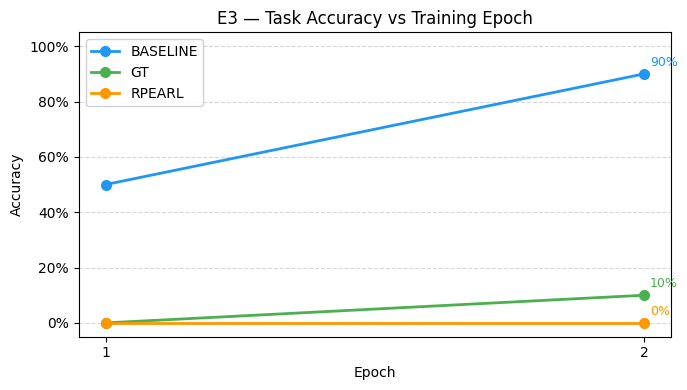

In [77]:
fig, ax = plt.subplots(figsize=(7, 4))

epochs_all = sorted(df["epoch"].unique())

for condition in ["BASELINE", "GT", "RPEARL"]:
    sub = agg[agg["condition"] == condition].sort_values("epoch")
    color = CONDITION_COLORS[condition]
    ax.plot(
        sub["epoch"], sub["mean"],
        marker="o", color=color, label=condition, linewidth=2, markersize=7,
    )
    if sub["std"].max() > 0:
        ax.fill_between(
            sub["epoch"],
            sub["mean"] - sub["std"],
            sub["mean"] + sub["std"],
            alpha=0.18, color=color,
        )
    # Annotate final point
    last = sub.iloc[-1]
    ax.annotate(
        f"{last['mean']*100:.0f}%",
        xy=(last["epoch"], last["mean"]),
        xytext=(4, 6), textcoords="offset points",
        fontsize=9, color=color,
    )

ax.set_xticks(epochs_all)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(-0.05, 1.05)
ax.set_title("E3 — Task Accuracy vs Training Epoch")
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Plot 2 — Per-seed accuracy (individual runs)

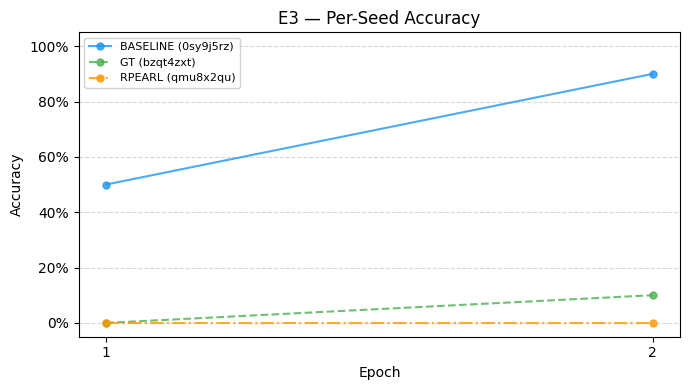

In [78]:
fig, ax = plt.subplots(figsize=(7, 4))

linestyles = ["-", "--", "-.", ":"]

for idx, (run_id, group) in enumerate(df.groupby("run_id")):
    condition = group["condition"].iloc[0]
    color = CONDITION_COLORS[condition]
    ls = linestyles[idx % len(linestyles)]
    sub = group.sort_values("epoch")
    label = f"{condition} ({run_id})"
    ax.plot(
        sub["epoch"], sub["accuracy"],
        marker="o", color=color, linestyle=ls,
        label=label, linewidth=1.5, markersize=5, alpha=0.8,
    )

ax.set_xticks(epochs_all)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(-0.05, 1.05)
ax.set_title("E3 — Per-Seed Accuracy")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Plot 3 — Final epoch bar chart

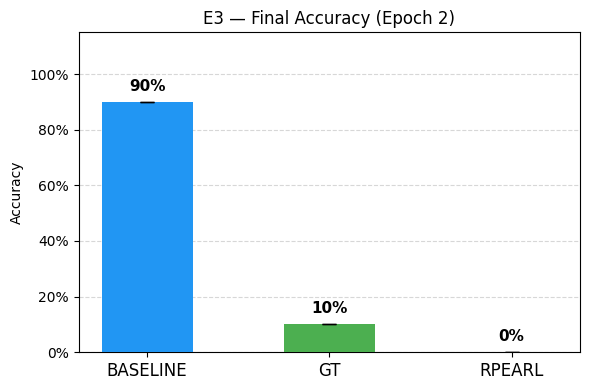

In [79]:
final_epoch = df["epoch"].max()
final = agg[agg["epoch"] == final_epoch].copy()
final = final.set_index("condition").reindex(["BASELINE", "GT", "RPEARL"])

fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(final))
bars = ax.bar(
    x, final["mean"],
    color=[CONDITION_COLORS[c] for c in final.index],
    yerr=final["std"], capsize=5,
    width=0.5, zorder=3,
)

for bar, (_, row) in zip(bars, final.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + row["std"] + 0.03,
        f"{row['mean']*100:.0f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

ax.set_xticks(x)
ax.set_xticklabels(final.index, fontsize=12)
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.15)
ax.set_title(f"E3 — Final Accuracy (Epoch {final_epoch})")
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

## Summary Table

In [80]:
summary = final[["mean", "std", "n"]].copy()
summary["accuracy"] = summary.apply(
    lambda r: f"{r['mean']*100:.0f}% ± {r['std']*100:.0f}%" if r["n"] > 1 else f"{r['mean']*100:.0f}%",
    axis=1,
)
summary["seeds"] = summary["n"].astype(int)

baseline_acc = final.loc["BASELINE", "mean"]
summary["delta_vs_baseline"] = summary["mean"].apply(
    lambda m: f"{(m - baseline_acc)*100:+.0f}pp"
)

display(summary[["accuracy", "seeds", "delta_vs_baseline"]])

,accuracy,seeds,delta_vs_baseline
condition,,,
BASELINE,90%,1,+0pp
GT,10%,1,-80pp
RPEARL,0%,1,-90pp


## LaTeX Table

In [81]:
latex_df = summary[["accuracy", "seeds", "delta_vs_baseline"]].rename(columns={
    "accuracy": "Accuracy (mean ± std)",
    "seeds": "Seeds",
    "delta_vs_baseline": r"$\Delta$ vs Baseline",
})
latex_df.index.name = "Condition"

print(latex_df.to_latex(
    caption=f"E3 Transferability \\& Permutation Equivariance — Final Accuracy (Epoch {final_epoch})",
    label="tab:e3_accuracy",
    escape=False,
))

\begin{table}
\caption{E3 Transferability \& Permutation Equivariance — Final Accuracy (Epoch 2)}
\label{tab:e3_accuracy}
\begin{tabular}{llrl}
\toprule
 & Accuracy (mean ± std) & Seeds & $\Delta$ vs Baseline \\
Condition &  &  &  \\
\midrule
BASELINE & 90% & 1 & +0pp \\
GT & 10% & 1 & -80pp \\
RPEARL & 0% & 1 & -90pp \\
\bottomrule
\end{tabular}
\end{table}

